In [12]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split


current_dir = Path(os.getcwd())
if str(current_dir) not in sys.path:
    sys.path.append(str(current_dir))



In [13]:
import tensorflow as tf

In [14]:
# Import our custom modules
# Ensure dataLoader.py, model.py, visualization.py are in the python path
from dataLoader import loadALSData
from model import createHybridModel      
from visualization import plot_training_history, visualize_prediction

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.16.2


In [15]:
DATA_DIR = "../../Data/processed"

# Load Data
print("Loading data...")
X, y = loadALSData(DATA_DIR)

if len(X) > 0:
    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"\nTraining Shape: {X_train.shape}")
    print(f"Testing Shape: {X_test.shape}")
else:
    print("No data found! Please check your path or run preprocessing.")

Loading data...
Loading subject data: P016_V3 (1/6)...
Missing modalities for P016_V3, skipping.
Expected: ../../Data/processed/P016_V3/P016_V3_T1.nii.gz
Loading subject data: C034_V2 (2/6)...
Missing modalities for C034_V2, skipping.
Expected: ../../Data/processed/C034_V2/C034_V2_T1.nii.gz
Loading subject data: C007_V1 (3/6)...
Missing modalities for C007_V1, skipping.
Expected: ../../Data/processed/C007_V1/C007_V1_T1.nii.gz
Loading subject data: P015_V1 (4/6)...
Missing modalities for P015_V1, skipping.
Expected: ../../Data/processed/P015_V1/P015_V1_T1.nii.gz
Loading subject data: C005_V1 (5/6)...
Missing modalities for C005_V1, skipping.
Expected: ../../Data/processed/C005_V1/C005_V1_T1.nii.gz
Loading subject data: P030_V3 (6/6)...
Missing modalities for P030_V3, skipping.
Expected: ../../Data/processed/P030_V3/P030_V3_T1.nii.gz
Loaded 0 subjects. Shape: (0,)
No data found! Please check your path or run preprocessing.


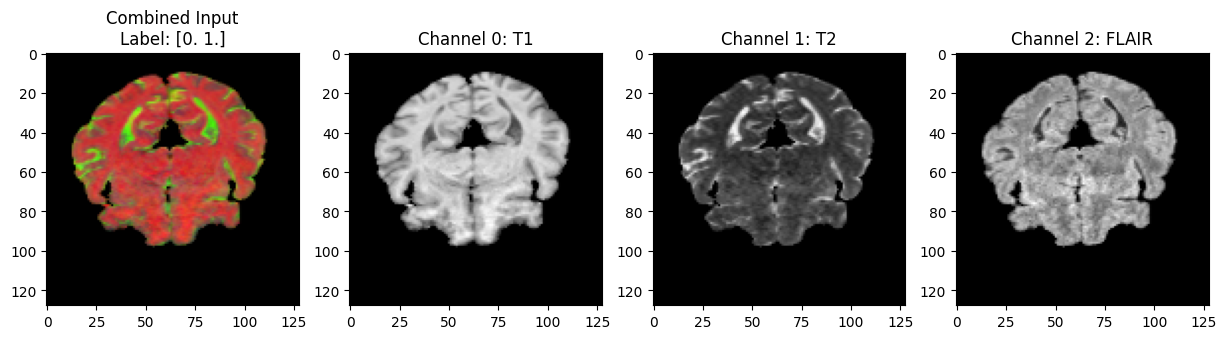

In [16]:
#Visualize Data
if len(X_train) > 0:
    idx = 0
    sample_img = X_train[idx]
    label = y_train[idx]
    
    # Normalize for display if needed (assuming data is raw floats, might need clipping for visualization)
    # Simple normalization for display: (img - min) / (max - min)
    disp_img = (sample_img - sample_img.min()) / (sample_img.max() - sample_img.min())

    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    
    # Combined (RGB interpretation)
    axes[0].imshow(disp_img)
    axes[0].set_title(f"Combined Input\nLabel: {label}")
    
    # Individual Channels
    axes[1].imshow(sample_img[:,:,0], cmap='gray')
    axes[1].set_title("Channel 0: T1")
    
    axes[2].imshow(sample_img[:,:,1], cmap='gray')
    axes[2].set_title("Channel 1: T2")
    
    axes[3].imshow(sample_img[:,:,2], cmap='gray')
    axes[3].set_title("Channel 2: FLAIR")
    
    plt.show()

In [17]:
# Create Model
model = createHybridModel()
model.summary()

Model: "Hybrid_RViT_ALS"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 158,653,570 (605.22 MB)

 Trainable params: 158,600,322 (605.01 MB)

 Non-trainable params: 53,248 (208.00 KB)

In [18]:

#Train Model
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 1e-4

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_model_notebook.weights.h5",
        save_best_only=True,
        save_weights_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54s/step - accuracy: 0.6667 - loss: 8.8968
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model_notebook.weights.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 64s 64s/step - accuracy: 0.6667 - loss: 8.8968 - val_accuracy: 0.0000e+00 - val_loss: 2.2311
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5000 - loss: 2.9559
Epoch 2: val_accuracy did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 2.9559 - val_accuracy: 0.0000e+00 - val_loss: 9.2787
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6667 - loss: 2.9041
Epoch 3: val_accuracy did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6667 - loss: 2.9041 - val_accuracy: 0.0000e+00 - val_loss: 9.3119
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6667 - loss: 3.5909
Epoch 4: val_accuracy did not improve from 0.00000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6667 - loss: 3.5909 - 

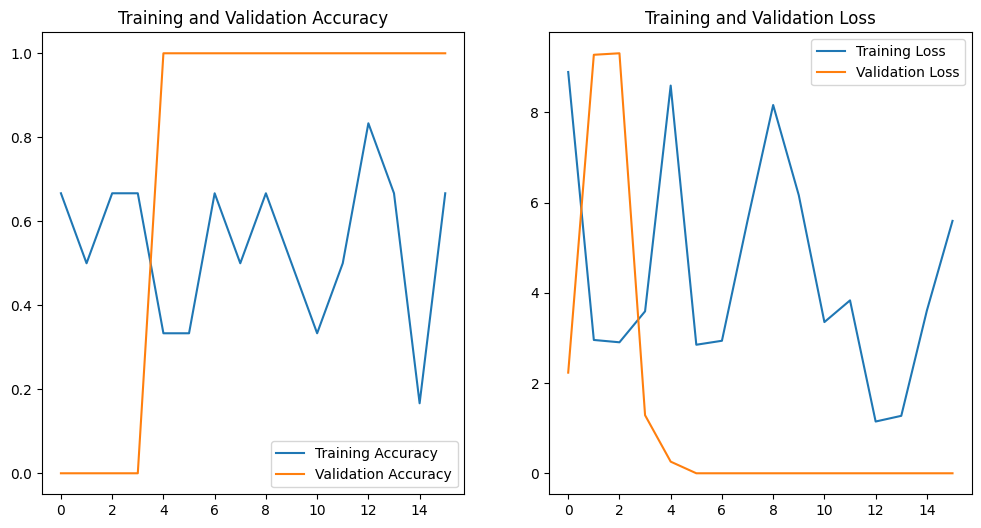

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 1.0000 - loss: 1.1921e-07
Final Test Accuracy: 100.00%


In [19]:
# Plot Accuracy & Loss
plot_training_history(history)

# Final Eval
loss, acc = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {acc*100:.2f}%")

/Users/adigyawali/anaconda3/envs/als-tf/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_250']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


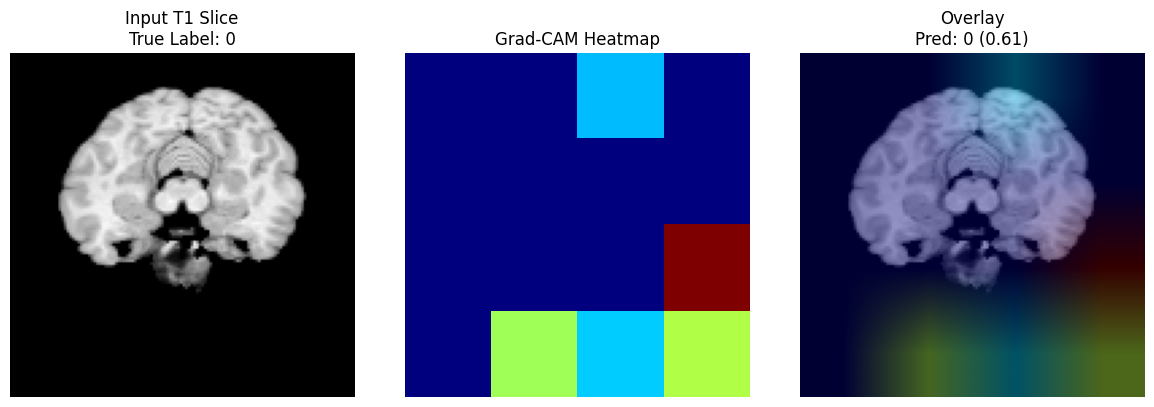

In [20]:
# Grad-Cam
if len(X_test) > 0:
    # Visualize the first test sample
    img_array = X_test[0:1] # Keep batch dim (1, 128, 128, 3)
    true_label = np.argmax(y_test[0])
    
    visualize_prediction(model, img_array, true_label)